# 03 — Forecast projection

Use the retention curve fitted in `02_retention_fit.ipynb` to project marketing-driven DAU lift forward under user-specified scenarios for future `excess_NP(t)`.

## Mechanic

```
marketing_DAU_lift(d) = Σ_{t≤d} excess_NP(t) × retention(d − t)
```

For projection, `excess_NP(t)` for `t > last_historical_date` is set by the chosen scenario.

## Default scenarios

- **Continuation** — extend `excess_NP` at the recent 14-day mean. ("Marketing spend holds steady.")
- **Decay 90d** — linear decay to zero over 90 days. ("Marketing winds down.")
- **Immediate stop** — `excess_NP = 0` from tomorrow. ("Marketing ends now; what's the residual lift from already-acquired cohorts?")

## Reading the result

The bottom panel (28-day MA) is the modeling deliverable — it's the moving-average view of the DAU lift you'd add to the mozaic baseline forecast to get a marketing-adjusted total. The daily-resolution panel above shows where the scenarios diverge mechanically.

**Prerequisite**: run `02_retention_fit.ipynb` end-to-end so `data/retention_fit.json` exists.


In [1]:
# [setup]
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Constants — must match 01 / 02 so the YoY-baseline subtraction is consistent.
BASELINE_START = pd.Timestamp('2026-02-01')
BASELINE_END = pd.Timestamp('2026-03-28')
CAMPAIGN_LAUNCH = pd.Timestamp('2026-04-06')

# How far to project. Default through 2026-12-31; bump out as needed.
FORECAST_END = pd.Timestamp('2026-12-31')

# How many days of recent excess_NP to average for the "continuation" scenario.
RECENT_WINDOW_DAYS = 14

# Forward-regime constants for the piecewise-linear marketing-lift projection.
# Used by scaled-fenix-model, plot-shipping, and forecast-comparison.
SLOPE_BREAK = pd.Timestamp('2026-07-01')
SLOPE_REDUCTION_FACTOR = 1.0 / 3.0
SLOPE_WINDOW_DAYS = 14

# Load fitted retention parameters from 02
DATA_DIR = Path('data')
fit_path = DATA_DIR / 'retention_fit.json'
assert fit_path.exists(), f"Run 02_retention_fit.ipynb's save-fit cell first; expected {fit_path.resolve()}"
with open(fit_path) as f:
    fit_meta = json.load(f)

A = fit_meta['a']
TAU_FAST = fit_meta['tau_fast']
TAU_SLOW = fit_meta['tau_slow']
INTEGRATED_RETENTION_MODEL = fit_meta['integrated_retention']


def retention(tau):
    """Two-component exponential retention (matches 02_retention_fit)."""
    return A * np.exp(-tau / TAU_FAST) + (1 - A) * np.exp(-tau / TAU_SLOW)


def predict_dau_lift(np_array):
    """Causal convolution: predicted_lift[d] = Σ_{t≤d} np[t] · retention(d-t)."""
    n = len(np_array)
    lags = np.arange(n)
    kernel = retention(lags)
    return np.convolve(np_array, kernel, mode='full')[:n]


print(f'Loaded retention fit: a={A:.3f}, τ_fast={TAU_FAST:.2f}d, τ_slow={TAU_SLOW:.2f}d')
print(f'Integrated retention: {INTEGRATED_RETENTION_MODEL:.3f} user-days / acquisition')
print(f'Forecast end:         {FORECAST_END.date()}')
print(f'Slope break:          {SLOPE_BREAK.date()} '
      f'(post-break slope = {SLOPE_REDUCTION_FACTOR:.3f} × initial)')


Loaded retention fit: a=0.860, τ_fast=0.62d, τ_slow=19.45d
Integrated retention: 3.247 user-days / acquisition
Forecast end:         2026-12-31
Slope break:          2026-07-01 (post-break slope = 0.333 × initial)


In [2]:
# [load-historical]
# Recompute excess_NP from cached 01 parquets using the same logic as 02.
# We don't import from 02 — these notebooks intentionally re-derive signals
# from cached data so each can be re-run independently.
new_profiles_2026 = pd.read_parquet(DATA_DIR / 'new_profiles_2026.parquet')
new_profiles_2025_aligned = pd.read_parquet(DATA_DIR / 'new_profiles_2025_aligned.parquet')
dau_2026 = pd.read_parquet(DATA_DIR / 'dau_2026.parquet')
dau_2025_aligned = pd.read_parquet(DATA_DIR / 'dau_2025_aligned.parquet')

np_index = new_profiles_2026.index.intersection(new_profiles_2025_aligned.index)
dau_index = dau_2026.index.intersection(dau_2025_aligned.index)
np_yoy = new_profiles_2026.loc[np_index] - new_profiles_2025_aligned.loc[np_index]
dau_yoy = dau_2026.loc[dau_index] - dau_2025_aligned.loc[dau_index]

np_baseline_mask = (np_yoy.index >= BASELINE_START) & (np_yoy.index <= BASELINE_END)
dau_baseline_mask = (dau_yoy.index >= BASELINE_START) & (dau_yoy.index <= BASELINE_END)
np_yoy_baseline = np_yoy.loc[np_baseline_mask, 'total_new_profiles'].mean()
dau_yoy_baseline = dau_yoy.loc[dau_baseline_mask, 'total_dau'].mean()

excess_NP_historical = (np_yoy['total_new_profiles'] - np_yoy_baseline).rename('excess_NP')
observed_DAU_lift_historical = (dau_yoy['total_dau'] - dau_yoy_baseline).rename('observed_DAU_lift')

LAST_HISTORICAL_DATE = excess_NP_historical.index.max()
recent_window_start = LAST_HISTORICAL_DATE - pd.Timedelta(days=RECENT_WINDOW_DAYS - 1)
recent_mask = excess_NP_historical.index >= recent_window_start
recent_excess_NP = excess_NP_historical[recent_mask]
RECENT_MEAN = recent_excess_NP.mean()
RECENT_PEAK = recent_excess_NP.max()

print(f'Historical signal: {excess_NP_historical.index.min().date()} to {LAST_HISTORICAL_DATE.date()}')
print(f'Recent {RECENT_WINDOW_DAYS}d excess_NP: mean={RECENT_MEAN:,.0f}/day, peak={RECENT_PEAK:,.0f}/day')


Historical signal: 2026-02-01 to 2026-05-16
Recent 14d excess_NP: mean=148,491/day, peak=229,129/day


In [3]:
# [define-scenarios]
# UNUSED — Defined 3 future-NP scenarios for the unscaled-projection approach (cells `project`, `plot-projections`). Superseded by the scaled-fenix model.
# # Future date index: day after last historical → forecast end.
# future_dates = pd.date_range(LAST_HISTORICAL_DATE + pd.Timedelta(days=1), FORECAST_END, freq='D')
# n_future = len(future_dates)


# def make_scenario(name, future_values, color):
#     """Build a full (historical + future) excess_NP series for a scenario."""
#     assert len(future_values) == n_future, f'expected {n_future} future values, got {len(future_values)}'
#     future_series = pd.Series(future_values, index=future_dates, name='excess_NP')
#     full = pd.concat([excess_NP_historical, future_series])
#     return {'name': name, 'excess_NP': full, 'color': color}


# # Scenario 1: continuation at the recent mean
# SCENARIO_CONTINUATION = make_scenario(
#     'continuation',
#     np.full(n_future, RECENT_MEAN),
#     color='C3',
# )

# # Scenario 2: linear decay over DECAY_DAYS, then zero
# DECAY_DAYS = 90
# decay_values = np.maximum(RECENT_MEAN * (1 - np.arange(n_future) / DECAY_DAYS), 0.0)
# SCENARIO_DECAY = make_scenario(
#     f'decay over {DECAY_DAYS}d',
#     decay_values,
#     color='C1',
# )

# # Scenario 3: immediate stop tomorrow
# SCENARIO_STOP = make_scenario(
#     'immediate stop',
#     np.zeros(n_future),
#     color='C7',
# )

# SCENARIOS = [SCENARIO_CONTINUATION, SCENARIO_DECAY, SCENARIO_STOP]

# print(f'Projection horizon: {n_future} days, {future_dates.min().date()} to {future_dates.max().date()}')
# print(f'\nFuture excess_NP per scenario (cumulative):')
# for s in SCENARIOS:
#     future = s['excess_NP'].loc[future_dates]
#     print(f'  {s["name"]:>20}: {future.sum():>15,.0f} total acquisitions')


In [4]:
# [project]
# UNUSED — Convolved the unscaled NP scenarios from `define-scenarios` through the retention kernel. Superseded by `scaled-fenix-model`.
# # Convolve each scenario's full excess_NP series through retention.
# for s in SCENARIOS:
#     s['predicted_DAU_lift'] = pd.Series(
#         predict_dau_lift(s['excess_NP'].values),
#         index=s['excess_NP'].index,
#         name=f'predicted_DAU_lift_{s["name"]}',
#     )

# print(f'Projected DAU lift snapshot (in DAU, single-day values):')
# print(f'{"scenario":>20}  {"last historical":>17}  {"+30d":>10}  {"+90d":>10}  {f"on {FORECAST_END.date()}":>16}')
# for s in SCENARIOS:
#     pred = s['predicted_DAU_lift']
#     at_last  = pred.loc[LAST_HISTORICAL_DATE]
#     at_30    = pred.loc[LAST_HISTORICAL_DATE + pd.Timedelta(days=30)]
#     at_90    = pred.loc[LAST_HISTORICAL_DATE + pd.Timedelta(days=90)]
#     at_end   = pred.iloc[-1]
#     print(f'  {s["name"]:>18}  {at_last:>+17,.0f}  {at_30:>+10,.0f}  {at_90:>+10,.0f}  {at_end:>+16,.0f}')


In [5]:
# [plot-projections]
# UNUSED — Plotted the unscaled NP-scenario projections. Superseded by `plot-marketing-projection`.
# fig, (ax_daily, ax_ma) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# # Daily-resolution panel
# ax_daily.plot(observed_DAU_lift_historical.index, observed_DAU_lift_historical,
#               'o', markersize=3, color='black', alpha=0.4, label='observed (historical)')
# for s in SCENARIOS:
#     pred = s['predicted_DAU_lift']
#     historical_part = pred.loc[:LAST_HISTORICAL_DATE]
#     future_part = pred.loc[LAST_HISTORICAL_DATE:]
#     ax_daily.plot(historical_part.index, historical_part, '-', linewidth=1, color=s['color'], alpha=0.3)
#     ax_daily.plot(future_part.index, future_part, '-', linewidth=2, color=s['color'], label=f'projected ({s["name"]})')
# ax_daily.axvline(LAST_HISTORICAL_DATE, color='black', linestyle='--', alpha=0.4, label='last historical day')
# ax_daily.axvline(CAMPAIGN_LAUNCH, color='black', linestyle=':', alpha=0.3)
# ax_daily.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
# ax_daily.set_title('Marketing-driven DAU lift — daily, by scenario')
# ax_daily.set_ylabel('DAU lift')
# ax_daily.legend(fontsize=9, loc='upper left')

# # 28-day moving-average panel (the modeling deliverable)
# obs_ma = observed_DAU_lift_historical.rolling(window=28, min_periods=14).mean()  # trailing
# ax_ma.plot(obs_ma.index, obs_ma, '-', linewidth=2, color='black', alpha=0.6, label='observed (28d MA)')
# for s in SCENARIOS:
#     pred = s['predicted_DAU_lift']
#     pred_ma = pred.rolling(window=28, min_periods=14).mean()  # trailing
#     ax_ma.plot(pred_ma.index, pred_ma, '-', linewidth=2, color=s['color'], label=f'{s["name"]} (28d MA)')
# ax_ma.axvline(LAST_HISTORICAL_DATE, color='black', linestyle='--', alpha=0.4)
# ax_ma.axvline(CAMPAIGN_LAUNCH, color='black', linestyle=':', alpha=0.3)
# ax_ma.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
# ax_ma.set_title('Marketing-driven DAU lift — 28-day moving average (modeling deliverable)')
# ax_ma.set_ylabel('DAU lift (28d MA)')
# ax_ma.set_xlabel('Date')
# ax_ma.legend(fontsize=9, loc='upper left')
# ax_ma.xaxis.set_major_locator(mdates.MonthLocator())
# ax_ma.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# fig.autofmt_xdate()
# plt.tight_layout()
# plt.show()


In [6]:
# [shipping-forecast]
# UNUSED — Alternative model: refit the convolution directly against (actuals − April forecast). Abandoned in favor of the simpler scale-the-Fenix-lift approach in `scaled-fenix-model`.
# # Refit the convolution model with TARGET = actuals − April forecast (the
# # all-mobile DAU gap), instead of the Fenix-only observed_DAU_lift used in 02.
# # Then project forward by convolving excess_NP (under a chosen NP scenario)
# # with the refit retention curve.
# #
# # This guarantees: convolved_lift(d) ≈ gap(d) historically, by construction of
# # the fit. Combined = April_forecast + convolved_lift therefore ≈ actuals.
# #
# # The convolution model — not piecewise extrapolation — drives the forward
# # projection. Default NP scenario: continuation at recent 14d mean.

# from scipy.optimize import minimize

# # --- Load actuals + April forecast (mobile, ex-Iran, ALL MOBILE rollup) ----
# APRIL_FORECAST_PATH = '/Users/brendanwells/work/mozaic-daily/data-official/2026-04/mobile_cps0.02_thresh32_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.gm-D.raw.parquet'
# JUNE_FORECAST_PATH = '/Users/brendanwells/work/mozaic-daily/data-official/2026-06/mobile_cps0.02_thresh32_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-17.gm-D.raw.parquet'


# def _load_mobile_total(path, data_type_filter=None):
#     df = pd.read_parquet(path)
#     rollup = df[(df['data_source'] == 'glean_mobile')
#                 & (df['country'] == 'ALL')
#                 & (df['app_name'] == 'ALL MOBILE')
#                 & (df['segment'] == '{}')].copy()
#     if data_type_filter is not None:
#         rollup = rollup[rollup['data_type'] == data_type_filter]
#     rollup['target_date'] = pd.to_datetime(rollup['target_date'])
#     return rollup.set_index('target_date').sort_index()['dau']


# april_full = _load_mobile_total(APRIL_FORECAST_PATH)
# actuals = _load_mobile_total(JUNE_FORECAST_PATH, data_type_filter='training')

# # Daily gap, aligned on dates where both exist
# gap_dates = april_full.index.intersection(actuals.index)
# gap_daily = (actuals.reindex(gap_dates) - april_full.reindex(gap_dates)).rename('gap')

# # --- Refit convolution with gap as target ----
# # Clean excess_NP: zero pre-campaign noise so the model starts at exactly 0
# # before CAMPAIGN_LAUNCH and only post-campaign acquisitions drive the lift.
# excess_NP_clean = excess_NP_historical.copy()
# excess_NP_clean[excess_NP_clean.index < CAMPAIGN_LAUNCH] = 0.0

# fit_index = excess_NP_clean.index.intersection(gap_daily.index)
# fit_NP = excess_NP_clean.reindex(fit_index, fill_value=0.0).values
# fit_gap = gap_daily.reindex(fit_index, fill_value=0.0).values

# # Easter mask — must match 02
# EASTER_MASK_DATES = pd.DatetimeIndex(sorted(set(
#     [pd.Timestamp('2026-04-05') + pd.Timedelta(days=d) for d in range(-2, 3)] +
#     [pd.Timestamp('2026-04-18') + pd.Timedelta(days=d) for d in range(-2, 3)]
# )))
# fit_mask = ~fit_index.isin(EASTER_MASK_DATES)
# post_mask = (fit_index >= CAMPAIGN_LAUNCH) & fit_mask

# EMPIRICAL_GAP_INTEGRATED = fit_gap[post_mask].sum() / fit_NP[post_mask].sum()


# def _retention(tau, a, tau_fast, tau_slow):
#     return a * np.exp(-tau / tau_fast) + (1.0 - a) * np.exp(-tau / tau_slow)


# def _predict_convolution(np_values, a, tau_fast, tau_slow):
#     n = len(np_values)
#     lags = np.arange(n)
#     kernel = _retention(lags, a, tau_fast, tau_slow)
#     return np.convolve(np_values, kernel, mode='full')[:n]


# def _integrated(a, tau_fast, tau_slow):
#     return a * tau_fast + (1.0 - a) * tau_slow


# DAU_LIFT_SCALE = 400_000
# TAU_SLOW_FLOOR = 20.0
# REG_WEIGHT = 0.001
# INTEGRAL_WEIGHT = 5.0
# SHAPE_ANCHOR_D1 = 0.30
# SHAPE_ANCHOR_WEIGHT = 0.5


# # Pre-compute the 28d trailing MA of the target (constant across iterations).
# fit_gap_ma_series = pd.Series(fit_gap, index=fit_index).rolling(window=28, min_periods=14).mean()


# def _gap_loss(params):
#     a, tau_fast, tau_slow = params

#     # Convolve, then take 28d trailing MA so the loss directly targets the
#     # smoothed metric we care about (shipping forecast is in 28d MA space).
#     predicted_daily = _predict_convolution(fit_NP, *params)
#     pred_ma = pd.Series(predicted_daily, index=fit_index).rolling(window=28, min_periods=14).mean()

#     valid = fit_mask & pred_ma.notna() & fit_gap_ma_series.notna()
#     ma_residuals = (pred_ma - fit_gap_ma_series).values[valid]
#     conv_term = np.mean(ma_residuals ** 2) / (DAU_LIFT_SCALE ** 2)

#     floor_violation = max(0.0, TAU_SLOW_FLOOR - tau_slow)
#     reg_term = REG_WEIGHT * floor_violation ** 2

#     integral_residual = _integrated(*params) - EMPIRICAL_GAP_INTEGRATED
#     integral_term = INTEGRAL_WEIGHT * integral_residual ** 2

#     d1_residual = _retention(1.0, *params) - SHAPE_ANCHOR_D1
#     shape_term = SHAPE_ANCHOR_WEIGHT * d1_residual ** 2

#     return conv_term + reg_term + integral_term + shape_term


# gap_fit_result = minimize(_gap_loss, [0.7, 5.0, 30.0],
#                           bounds=[(0.0, 1.0), (0.5, 50.0), (5.0, 1000.0)],
#                           method='L-BFGS-B')
# gap_a, gap_tau_fast, gap_tau_slow = gap_fit_result.x

# # --- Forward projection: continuation NP scenario through FORECAST_END ----
# # Pre-CAMPAIGN_LAUNCH NPs are forced to 0 here too (consistent with the fit).
# # Post-CAMPAIGN_LAUNCH: actual historical NPs through LAST_HISTORICAL_DATE,
# # then continuation at RECENT_MEAN through FORECAST_END.
# full_index = pd.date_range(excess_NP_historical.index.min(), FORECAST_END, freq='D')
# full_excess_NP = pd.Series(RECENT_MEAN, index=full_index)
# full_excess_NP[full_excess_NP.index < CAMPAIGN_LAUNCH] = 0.0
# full_excess_NP.loc[excess_NP_clean.index] = excess_NP_clean.values

# gap_predicted_daily = pd.Series(
#     _predict_convolution(full_excess_NP.values, *gap_fit_result.x),
#     index=full_index,
#     name='gap_predicted',
# )

# shipping_forecast = gap_predicted_daily.rolling(window=28, min_periods=14).mean().rename('shipping_forecast')

# # In-fit diagnostics — report MA-based residuals (the loss target) so the
# # numbers here align with the validation cell's residual stats.
# fit_predicted_daily = _predict_convolution(fit_NP, *gap_fit_result.x)
# fit_pred_ma = pd.Series(fit_predicted_daily, index=fit_index).rolling(window=28, min_periods=14).mean()
# ma_valid = fit_mask & fit_pred_ma.notna() & fit_gap_ma_series.notna()
# fit_ma_residuals = (fit_pred_ma - fit_gap_ma_series).values[ma_valid]
# fit_rmse = np.sqrt(np.mean(fit_ma_residuals ** 2))

# # Context series for plot-shipping
# model_ma = SCENARIO_CONTINUATION['predicted_DAU_lift'].rolling(window=28, min_periods=14).mean()
# observed_dau_lift_ma = observed_DAU_lift_historical.rolling(window=28, min_periods=14).mean()

# print(f'Refit target: actuals − April forecast (all mobile, ex-Iran)')
# print(f'Fit window: {fit_index.min().date()} → {fit_index.max().date()} '
#       f'({int(post_mask.sum())} post-campaign fit-days, excl. Easter)')
# print(f'In-fit RMSE on 28d MA of gap: {fit_rmse:,.0f} DAU')
# print()
# print(f'Refit retention parameters:')
# print(f'  a       (fast-churn fraction):  {gap_a:.3f}')
# print(f'  τ_fast  (fast half-life):       {gap_tau_fast:.2f} days')
# print(f'  τ_slow  (slow tail half-life):  {gap_tau_slow:.2f} days')
# print(f'  Integrated retention: model={_integrated(*gap_fit_result.x):.3f}, '
#       f'empirical target={EMPIRICAL_GAP_INTEGRATED:.3f}')
# print()
# print(f'Retention at key lags:')
# for tau in [1, 3, 7, 14, 28, 60, 90]:
#     print(f'  D{tau:>2}: {_retention(tau, *gap_fit_result.x):.3f}')
# print()
# print(f'Shipping forecast (28d trailing MA of convolved gap, continuation NPs):')
# for d in [pd.Timestamp('2026-04-03'), LAST_HISTORICAL_DATE, pd.Timestamp('2026-07-01'),
#           pd.Timestamp('2026-09-01'), pd.Timestamp('2026-12-15'), FORECAST_END]:
#     if d in shipping_forecast.index and pd.notna(shipping_forecast.loc[d]):
#         print(f'  {d.strftime("%Y-%m-%d")}: {shipping_forecast.loc[d]:>+14,.0f}')


In [7]:
# [plot-shipping]
# UNUSED — Plot for the abandoned `shipping-forecast` model.
# fig, ax = plt.subplots(figsize=(14, 6))

# # Observed 28d MA (truncated to historical span)
# obs_ma = observed_DAU_lift_historical.rolling(window=28, min_periods=14).mean()  # trailing
# ax.plot(obs_ma.index, obs_ma, 'o-', markersize=3, linewidth=1, color='black', alpha=0.4,
#         label='observed (28d MA)')

# # Model 28d MA (continuation scenario — shows what the convolution implies past today)
# ax.plot(model_ma.index, model_ma, '-', linewidth=1.2, color='C0', alpha=0.55,
#         label='convolution model 28d MA (continuation)')

# # Shipping forecast
# ax.plot(shipping_forecast.index, shipping_forecast, '-', linewidth=2.5, color='C3',
#         label='shipping forecast (piecewise)')

# # Vertical markers
# ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle=':', alpha=0.4, label=f'campaign launch ({CAMPAIGN_LAUNCH.date()})')
# ax.axvline(LAST_HISTORICAL_DATE, color='black', linestyle='--', alpha=0.4, label=f'today ({LAST_HISTORICAL_DATE.date()})')
# ax.axvline(SLOPE_BREAK, color='black', linestyle='-.', alpha=0.4, label=f'slope break ({SLOPE_BREAK.date()})')

# ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
# ax.set_title('Shipping forecast — marketing-driven DAU lift, 28-day MA')
# ax.set_ylabel('DAU lift (28d MA)')
# ax.set_xlabel('Date')
# ax.legend(fontsize=9, loc='upper left')
# ax.xaxis.set_major_locator(mdates.MonthLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# fig.autofmt_xdate()
# plt.tight_layout()
# plt.show()


In [8]:
# [forecast-comparison]
# UNUSED — Side-by-side of the shipping-forecast composite vs April baseline. References abandoned `shipping-forecast` outputs.
# # Test whether the marketing model closes the gap between the April forecast
# # (which didn't know about the campaign) and actuals.
# #
# # April forecast (mobile, ex-Iran, all-mobile rollup): "no marketing" baseline.
# # Actuals (mobile, ex-Iran, all-mobile rollup): truth, latest available.
# # April forecast + marketing model: our hypothesis.

# # Forecast file paths in the main repo (read-only from this worktree).
# APRIL_FORECAST_PATH = '/Users/brendanwells/work/mozaic-daily/data-official/2026-04/mobile_cps0.02_thresh32_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.gm-D.raw.parquet'
# JUNE_FORECAST_PATH = '/Users/brendanwells/work/mozaic-daily/data-official/2026-06/mobile_cps0.02_thresh32_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-17.gm-D.raw.parquet'


# def load_mobile_total(path, data_type_filter=None):
#     """Mobile DAU at the country=ALL, app_name='ALL MOBILE' rollup (ex-Iran)."""
#     df = pd.read_parquet(path)
#     rollup = df[(df['data_source'] == 'glean_mobile')
#                 & (df['country'] == 'ALL')
#                 & (df['app_name'] == 'ALL MOBILE')
#                 & (df['segment'] == '{}')].copy()
#     if data_type_filter is not None:
#         rollup = rollup[rollup['data_type'] == data_type_filter]
#     rollup['target_date'] = pd.to_datetime(rollup['target_date'])
#     return rollup.set_index('target_date').sort_index()['dau']


# # April forecast file: keep both training (actuals through 2026-04-01) and
# # forecast (2026-04-02 onward) so the trailing MA has continuous input.
# april_full = load_mobile_total(APRIL_FORECAST_PATH)
# april_forecast_only = load_mobile_total(APRIL_FORECAST_PATH, data_type_filter='forecast')
# april_forecast_start = april_forecast_only.index.min()

# # Latest actuals: training portion of the June forecast file
# actuals = load_mobile_total(JUNE_FORECAST_PATH, data_type_filter='training')

# print(f'April file:    full series {april_full.index.min().date()} → {april_full.index.max().date()} '
#       f'(forecast starts {april_forecast_start.date()})')
# print(f'Actuals (June file training): {actuals.index.min().date()} → {actuals.index.max().date()}')

# # Build the comparison series in 28d trailing MA space
# PLOT_START = pd.Timestamp('2026-02-01')
# PLOT_END = pd.Timestamp('2026-12-31')
# plot_index = pd.date_range(PLOT_START, PLOT_END, freq='D')

# actuals_ma = actuals.rolling(window=28, min_periods=14).mean().reindex(plot_index)
# april_ma = april_full.rolling(window=28, min_periods=14).mean().reindex(plot_index)
# # Combined = April forecast (its MA) + marketing lift (already 28d MA).
# # Outside the shipping_forecast date range the marketing contribution is 0.
# marketing_aligned = shipping_forecast.reindex(plot_index).fillna(0.0)
# combined_ma = april_ma + marketing_aligned

# # Sanity print: values at key dates
# print(f'\nValues at key dates (28d MA, DAU):')
# print(f'{"date":>12}  {"actuals":>12}  {"april fcst":>12}  {"fcst + mktg":>12}  {"actuals − fcst":>16}  {"explained":>12}')
# for d in [pd.Timestamp('2026-04-01'), pd.Timestamp('2026-05-01'),
#           LAST_HISTORICAL_DATE, SLOPE_BREAK,
#           pd.Timestamp('2026-09-01'), pd.Timestamp('2026-12-15')]:
#     if d not in plot_index:
#         continue
#     a = actuals_ma.loc[d]
#     f = april_ma.loc[d]
#     c = combined_ma.loc[d]
#     gap = (a - f) if pd.notna(a) and pd.notna(f) else float('nan')
#     explained = (c - f) if pd.notna(c) and pd.notna(f) else float('nan')
#     a_s = f'{a:>+12,.0f}' if pd.notna(a) else f'{"":>12}'
#     f_s = f'{f:>+12,.0f}' if pd.notna(f) else f'{"":>12}'
#     c_s = f'{c:>+12,.0f}' if pd.notna(c) else f'{"":>12}'
#     g_s = f'{gap:>+16,.0f}' if pd.notna(gap) else f'{"":>16}'
#     e_s = f'{explained:>+12,.0f}' if pd.notna(explained) else f'{"":>12}'
#     print(f'  {d.strftime("%Y-%m-%d"):>10}  {a_s}  {f_s}  {c_s}  {g_s}  {e_s}')


In [9]:
# [plot-forecast-comparison]
# UNUSED — Plot for the abandoned `forecast-comparison` view.
# fig, ax = plt.subplots(figsize=(14, 6))

# ax.plot(actuals_ma.index, actuals_ma, '-', linewidth=2, color='black', alpha=0.85,
#         label='actuals (28d trailing MA)')
# ax.plot(april_ma.index, april_ma, '-', linewidth=2, color='C0', alpha=0.85,
#         label='April forecast (28d trailing MA)')
# ax.plot(combined_ma.index, combined_ma, '-', linewidth=2, color='C3', alpha=0.85,
#         label='April forecast + marketing model (28d trailing MA)')

# ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle=':', alpha=0.4, label=f'campaign launch ({CAMPAIGN_LAUNCH.date()})')
# ax.axvline(LAST_HISTORICAL_DATE, color='black', linestyle='--', alpha=0.4, label=f'last actuals ({actuals.index.max().date()})')
# ax.axvline(SLOPE_BREAK, color='black', linestyle='-.', alpha=0.4, label=f'slope break ({SLOPE_BREAK.date()})')

# ax.set_title('Mobile DAU (ex-Iran) — does April forecast + marketing model match actuals?')
# ax.set_ylabel('Mobile DAU (28d trailing MA)')
# ax.set_xlabel('Date')
# ax.legend(fontsize=9, loc='lower right')
# ax.set_xlim(PLOT_START, PLOT_END)
# ax.xaxis.set_major_locator(mdates.MonthLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# fig.autofmt_xdate()
# plt.tight_layout()
# plt.show()


In [10]:
# [actuals-minus-marketing]
# UNUSED — Validation view for the abandoned `shipping-forecast` model. Superseded by `plot-scaled-validation` which uses the scaled-fenix model.
# # Validation view: if the marketing model is correct, then
# #   (actuals − marketing model) should land on top of the April forecast
# # over the historical period. Past the last actuals, only the forecast is shown.

# # Compute "actuals − marketing model" in 28d trailing MA space.
# # actuals_ma was computed in forecast-comparison; shipping_forecast is already
# # in 28d MA space.
# shipping_in_actuals_index = shipping_forecast.reindex(actuals_ma.index).fillna(0)
# actuals_minus_marketing = actuals_ma - shipping_in_actuals_index

# # Only plot the "minus marketing" line where actuals exist
# have_actuals = actuals_ma.notna()

# fig, ax = plt.subplots(figsize=(14, 6))

# ax.plot(actuals_minus_marketing.index[have_actuals],
#         actuals_minus_marketing[have_actuals],
#         '-', linewidth=2, color='C2',
#         label='actuals − marketing model (28d MA)')

# ax.plot(april_ma.index, april_ma,
#         '-', linewidth=2, color='C0', alpha=0.85,
#         label='April forecast (28d MA, full horizon)')

# ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle=':', alpha=0.4,
#            label=f'campaign launch ({CAMPAIGN_LAUNCH.date()})')
# ax.axvline(actuals.index.max(), color='black', linestyle='--', alpha=0.4,
#            label=f'last actuals ({actuals.index.max().date()})')

# ax.set_title('Validation: actuals − marketing model vs April forecast (ex-Iran mobile)')
# ax.set_ylabel('Mobile DAU (28d trailing MA)')
# ax.set_xlabel('Date')
# ax.legend(fontsize=9, loc='lower right')
# ax.set_xlim(PLOT_START, PLOT_END)
# ax.xaxis.set_major_locator(mdates.MonthLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# fig.autofmt_xdate()
# plt.tight_layout()
# plt.show()

# # Print residual statistics over the validation window
# valid_residual = (actuals_minus_marketing - april_ma).dropna()
# print(f'Residual: (actuals − marketing) − April forecast, 28d MA')
# print(f'  N days: {len(valid_residual)}')
# print(f'  Mean:   {valid_residual.mean():>+10,.0f} DAU')
# print(f'  Std:    {valid_residual.std():>+10,.0f} DAU')
# print(f'  Min:    {valid_residual.min():>+10,.0f} DAU (at {valid_residual.idxmin().date()})')
# print(f'  Max:    {valid_residual.max():>+10,.0f} DAU (at {valid_residual.idxmax().date()})')


In [11]:
# [scaled-fenix-model]
# Build the marketing-lift model. Two-stage construction:
#   1) Historical (campaign launch → LAST_HISTORICAL_DATE):
#        scaled_fenix(d) = SCALE_FACTOR · (excess_NP_clean ⊛ retention)(d)
#      where SCALE_FACTOR makes the 28d-MA post-campaign mean of scaled_fenix
#      match the 28d-MA post-campaign mean of (actuals − April forecast) at
#      the ex-Iran ALL-MOBILE rollup, excluding Easter.
#   2) Forward (LAST_HISTORICAL_DATE + 1 → FORECAST_END):
#        piecewise linear pinned to scaled_fenix at LAST_HISTORICAL_DATE.
#        Slope = OLS slope on scaled_fenix's 28d MA over its trailing
#        SLOPE_WINDOW_DAYS, reduced by SLOPE_REDUCTION_FACTOR after SLOPE_BREAK.

# --- Mobile actuals + April forecast at ex-Iran ALL-MOBILE rollup ---
APRIL_FORECAST_PATH = '/Users/brendanwells/work/mozaic-daily/data-official/2026-04/mobile_cps0.02_thresh32_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.gm-D.raw.parquet'
JUNE_FORECAST_PATH = '/Users/brendanwells/work/mozaic-daily/data-official/2026-06/mobile_cps0.02_thresh32_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-17.gm-D.raw.parquet'


def _mobile_total(path, data_type_filter=None):
    df = pd.read_parquet(path)
    rollup = df[(df['data_source'] == 'glean_mobile')
                & (df['country'] == 'ALL')
                & (df['app_name'] == 'ALL MOBILE')
                & (df['segment'] == '{}')].copy()
    if data_type_filter is not None:
        rollup = rollup[rollup['data_type'] == data_type_filter]
    rollup['target_date'] = pd.to_datetime(rollup['target_date'])
    return rollup.set_index('target_date').sort_index()['dau']


april_full_mobile = _mobile_total(APRIL_FORECAST_PATH)
actuals_mobile = _mobile_total(JUNE_FORECAST_PATH, data_type_filter='training')

# --- 1) Historical: Fenix lift convolution, then scale to gap magnitude ---
# Pre-campaign noise zeroed so the model is exactly 0 before launch.
excess_NP_clean = excess_NP_historical.copy()
excess_NP_clean[excess_NP_clean.index < CAMPAIGN_LAUNCH] = 0.0

fenix_lift_daily = pd.Series(
    predict_dau_lift(excess_NP_clean.values),
    index=excess_NP_clean.index,
    name='fenix_lift_daily',
)

# Gap = actuals − April forecast at the rollup; daily then 28d MA.
gap_index = april_full_mobile.index.intersection(actuals_mobile.index)
gap_daily = (actuals_mobile.reindex(gap_index)
             - april_full_mobile.reindex(gap_index)).rename('gap_daily')

# Easter mask — same dates as 02 and shipping-forecast.
EASTER_MASK_DATES = pd.DatetimeIndex(sorted(set(
    [pd.Timestamp('2026-04-05') + pd.Timedelta(days=d) for d in range(-2, 3)] +
    [pd.Timestamp('2026-04-18') + pd.Timedelta(days=d) for d in range(-2, 3)]
)))

gap_ma = gap_daily.rolling(window=28, min_periods=14).mean()
fenix_lift_ma = fenix_lift_daily.rolling(window=28, min_periods=14).mean()

# Compare 28d MAs on dates that are post-campaign, non-Easter, and have valid
# MA values in both series.
ma_compare_index = gap_ma.index.intersection(fenix_lift_ma.index)
compare_mask = (
    (ma_compare_index >= CAMPAIGN_LAUNCH)
    & (~ma_compare_index.isin(EASTER_MASK_DATES))
    & gap_ma.reindex(ma_compare_index).notna()
    & fenix_lift_ma.reindex(ma_compare_index).notna()
)
compare_dates = ma_compare_index[compare_mask]
gap_ma_mean_post = gap_ma.reindex(compare_dates).mean()
fenix_lift_ma_mean_post = fenix_lift_ma.reindex(compare_dates).mean()
SCALE_FACTOR = float(gap_ma_mean_post / fenix_lift_ma_mean_post)

scaled_fenix_daily = (SCALE_FACTOR * fenix_lift_daily).rename('scaled_fenix_daily')
scaled_fenix_ma = scaled_fenix_daily.rolling(window=28, min_periods=14).mean()

# --- 2) Forward: piecewise-linear extension ---
# Anchor slope: OLS on the last SLOPE_WINDOW_DAYS of scaled_fenix's 28d MA.
slope_window_end = LAST_HISTORICAL_DATE
slope_window_start = slope_window_end - pd.Timedelta(days=SLOPE_WINDOW_DAYS - 1)
slope_window_dates = pd.date_range(slope_window_start, slope_window_end, freq='D')
slope_window_y = scaled_fenix_ma.reindex(slope_window_dates).values
slope_window_x = np.arange(SLOPE_WINDOW_DAYS, dtype=float)
slope_valid = ~np.isnan(slope_window_y)
slope_coef = np.polyfit(slope_window_x[slope_valid], slope_window_y[slope_valid], 1)
ANCHOR_SLOPE = float(slope_coef[0])

# Pin the daily forward series to the daily historical value at LAST_HISTORICAL_DATE
# so daily↔daily is continuous (the 28d MA inherits continuity after a ~14d ramp).
pin_value = float(scaled_fenix_daily.loc[LAST_HISTORICAL_DATE])

forward_dates = pd.date_range(LAST_HISTORICAL_DATE + pd.Timedelta(days=1), FORECAST_END, freq='D')
days_to_break = (SLOPE_BREAK - LAST_HISTORICAL_DATE).days
value_at_break = pin_value + ANCHOR_SLOPE * days_to_break
forward_values = np.empty(len(forward_dates))
for i, day in enumerate(forward_dates):
    if day <= SLOPE_BREAK:
        forward_values[i] = pin_value + ANCHOR_SLOPE * (day - LAST_HISTORICAL_DATE).days
    else:
        forward_values[i] = value_at_break + ANCHOR_SLOPE * SLOPE_REDUCTION_FACTOR * (day - SLOPE_BREAK).days
forward_series = pd.Series(forward_values, index=forward_dates, name='forward')

# --- 3) Stitch full marketing-lift series ---
marketing_lift_daily = pd.concat([scaled_fenix_daily, forward_series]).rename('marketing_lift_daily')
marketing_lift_ma = marketing_lift_daily.rolling(window=28, min_periods=14).mean().rename('marketing_lift_ma')

# Diagnostics
print(f'Scale factor: SCALE_FACTOR = {SCALE_FACTOR:.3f}')
print(f'  Fenix lift 28d-MA post-campaign mean (unscaled): {fenix_lift_ma_mean_post:>+12,.0f} DAU')
print(f'  Gap         28d-MA post-campaign mean:            {gap_ma_mean_post:>+12,.0f} DAU')
print()
print(f'Anchor slope: {ANCHOR_SLOPE:>+10,.1f} DAU/day '
      f'(OLS on last {SLOPE_WINDOW_DAYS}d of scaled_fenix 28d MA)')
print(f'Post-break slope ({SLOPE_BREAK.date()} → {FORECAST_END.date()}): '
      f'{ANCHOR_SLOPE * SLOPE_REDUCTION_FACTOR:>+10,.1f} DAU/day')
print()
print(f'Marketing-lift model snapshot:')
print(f'  {"date":>10}  {"daily":>14}  {"28d MA":>14}')
for day in [CAMPAIGN_LAUNCH, pd.Timestamp('2026-05-01'), LAST_HISTORICAL_DATE,
            SLOPE_BREAK, pd.Timestamp('2026-09-01'),
            pd.Timestamp('2026-12-15'), FORECAST_END]:
    val_daily = marketing_lift_daily.get(day, float('nan'))
    val_ma = marketing_lift_ma.get(day, float('nan'))
    daily_str = f'{val_daily:>+14,.0f}' if pd.notna(val_daily) else f'{"":>14}'
    ma_str = f'{val_ma:>+14,.0f}' if pd.notna(val_ma) else f'{"":>14}'
    print(f'  {day.strftime("%Y-%m-%d"):>10}  {daily_str}  {ma_str}')


Scale factor: SCALE_FACTOR = 1.064
  Fenix lift 28d-MA post-campaign mean (unscaled):     +162,507 DAU
  Gap         28d-MA post-campaign mean:                +172,953 DAU

Anchor slope:  +11,344.3 DAU/day (OLS on last 14d of scaled_fenix 28d MA)
Post-break slope (2026-07-01 → 2026-12-31):   +3,781.4 DAU/day

Marketing-lift model snapshot:
        date           daily          28d MA
  2026-04-06         +52,023          +1,858
  2026-05-01        +331,144        +188,435
  2026-05-16        +579,474        +362,140
  2026-07-01      +1,101,314        +948,166
  2026-09-01      +1,335,764      +1,284,715
  2026-12-15      +1,732,816      +1,681,767
  2026-12-31      +1,793,319      +1,742,270


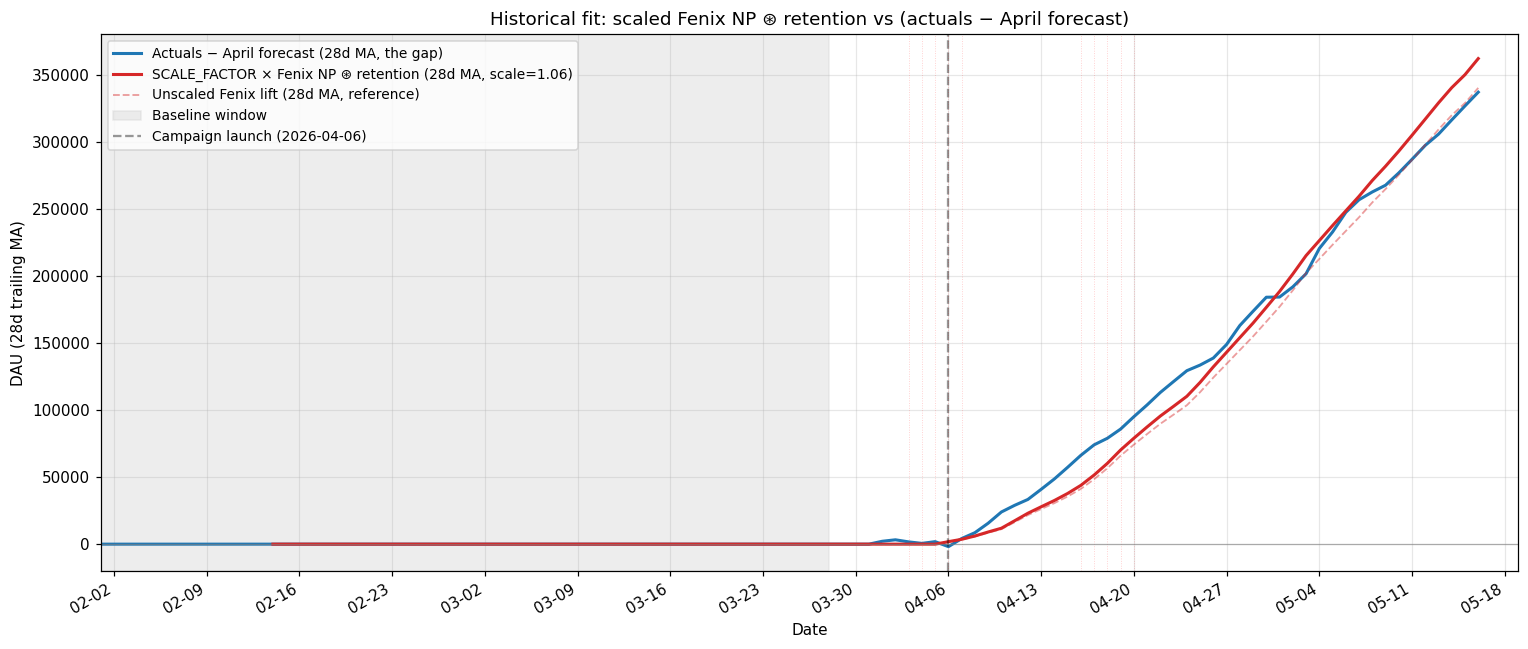

Residual (scaled_fenix_ma − gap_ma), post-campaign non-Easter days:
  N days: 34
  Mean:           -0 DAU  (~0 by construction of SCALE_FACTOR)
  Std:       +14,443 DAU
  RMSE:      +14,229 DAU


In [12]:
# [plot-scaled-fit]
# Validation A: does SCALE_FACTOR × Fenix lift match the all-mobile gap over the
# historical post-campaign window? Compare 28d trailing MAs.

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(gap_ma.index, gap_ma, '-', linewidth=2, color='C0',
        label='Actuals − April forecast (28d MA, the gap)')
ax.plot(scaled_fenix_ma.index, scaled_fenix_ma, '-', linewidth=2, color='C3',
        label=f'SCALE_FACTOR × Fenix NP ⊛ retention (28d MA, scale={SCALE_FACTOR:.2f})')
ax.plot(fenix_lift_ma.index, fenix_lift_ma, '--', linewidth=1.2, color='C3', alpha=0.45,
        label='Unscaled Fenix lift (28d MA, reference)')

ax.axvspan(BASELINE_START, BASELINE_END, color='lightgrey', alpha=0.4,
           label='Baseline window')
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4,
           label=f'Campaign launch ({CAMPAIGN_LAUNCH.date()})')
for day in EASTER_MASK_DATES:
    ax.axvline(day, color='red', linestyle=':', linewidth=0.6, alpha=0.2)
ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)

ax.set_title('Historical fit: scaled Fenix NP ⊛ retention vs (actuals − April forecast)')
ax.set_ylabel('DAU (28d trailing MA)')
ax.set_xlabel('Date')
ax.set_xlim(BASELINE_START, LAST_HISTORICAL_DATE + pd.Timedelta(days=3))
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

fit_residuals = (scaled_fenix_ma - gap_ma).reindex(compare_dates)
print(f'Residual (scaled_fenix_ma − gap_ma), post-campaign non-Easter days:')
print(f'  N days: {len(fit_residuals)}')
print(f'  Mean:   {fit_residuals.mean():>+10,.0f} DAU  (~0 by construction of SCALE_FACTOR)')
print(f'  Std:    {fit_residuals.std():>+10,.0f} DAU')
print(f'  RMSE:   {np.sqrt((fit_residuals ** 2).mean()):>+10,.0f} DAU')


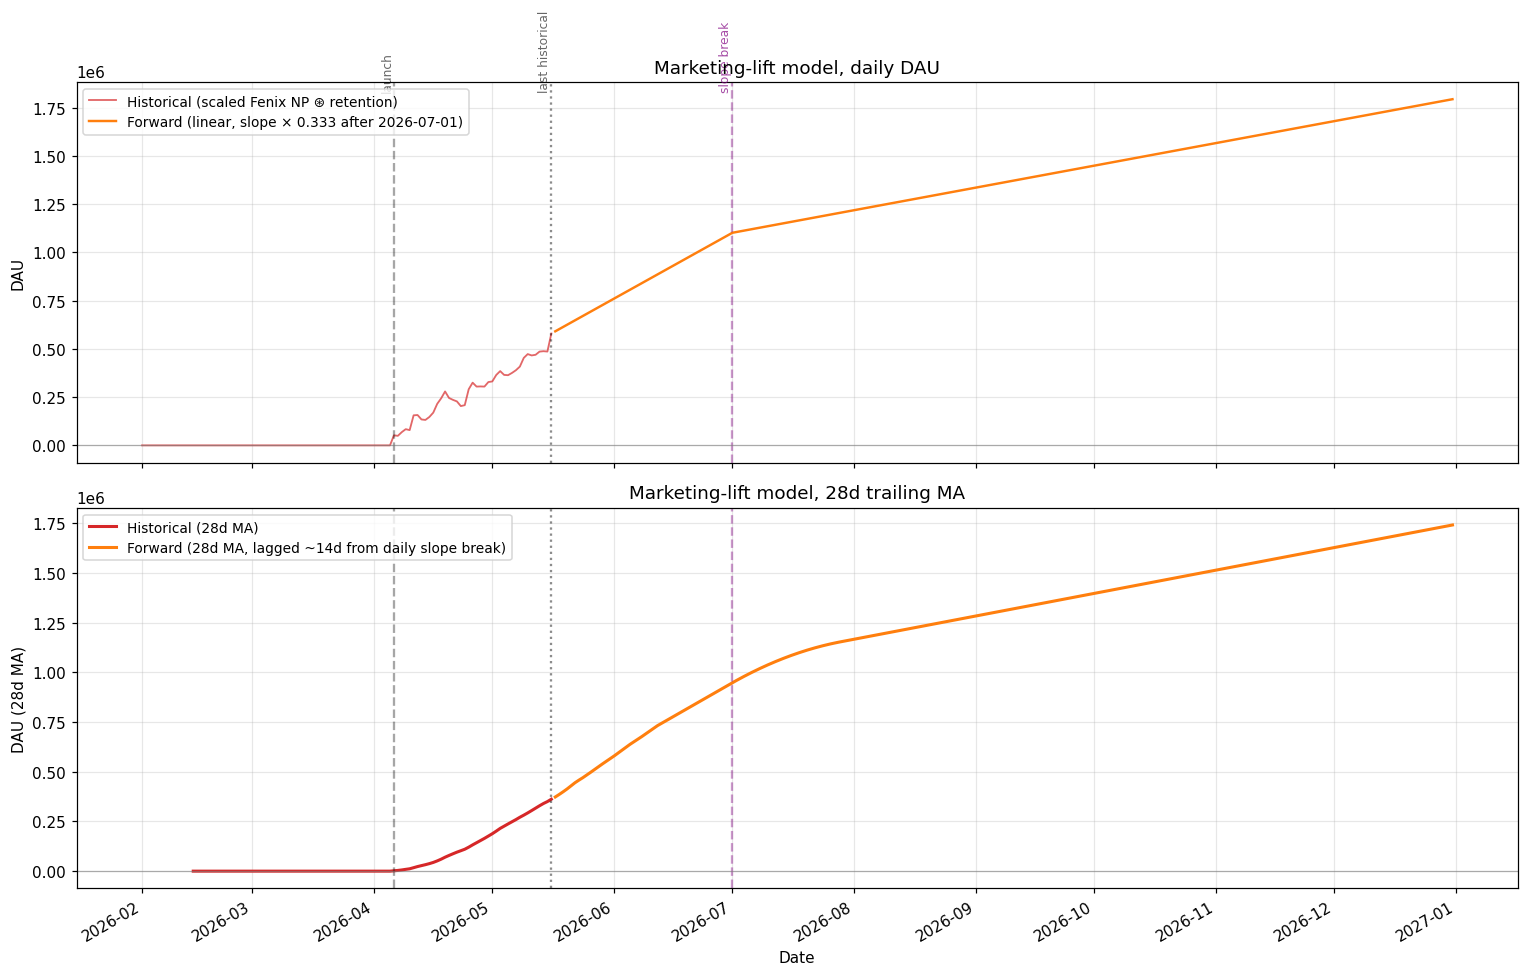

In [13]:
# [plot-marketing-projection]
# Full marketing-lift model: historical (scaled NP ⊛ retention) + forward
# (piecewise linear). Top panel: daily series. Bottom panel: 28d MA.

fig, (ax_daily, ax_ma) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

hist_mask = marketing_lift_daily.index <= LAST_HISTORICAL_DATE
fwd_mask = marketing_lift_daily.index > LAST_HISTORICAL_DATE

ax_daily.plot(marketing_lift_daily.index[hist_mask], marketing_lift_daily[hist_mask],
              '-', linewidth=1.2, color='C3', alpha=0.7,
              label='Historical (scaled Fenix NP ⊛ retention)')
ax_daily.plot(marketing_lift_daily.index[fwd_mask], marketing_lift_daily[fwd_mask],
              '-', linewidth=1.6, color='C1',
              label=f'Forward (linear, slope × {SLOPE_REDUCTION_FACTOR:.3f} after {SLOPE_BREAK.date()})')
ax_daily.set_title('Marketing-lift model, daily DAU')
ax_daily.set_ylabel('DAU')
ax_daily.legend(fontsize=9, loc='upper left')

ma_hist = marketing_lift_ma.index <= LAST_HISTORICAL_DATE
ma_fwd = marketing_lift_ma.index > LAST_HISTORICAL_DATE
ax_ma.plot(marketing_lift_ma.index[ma_hist], marketing_lift_ma[ma_hist],
           '-', linewidth=2, color='C3', label='Historical (28d MA)')
ax_ma.plot(marketing_lift_ma.index[ma_fwd], marketing_lift_ma[ma_fwd],
           '-', linewidth=2, color='C1',
           label='Forward (28d MA, lagged ~14d from daily slope break)')
ax_ma.set_title('Marketing-lift model, 28d trailing MA')
ax_ma.set_ylabel('DAU (28d MA)')
ax_ma.set_xlabel('Date')
ax_ma.legend(fontsize=9, loc='upper left')

for ax in (ax_daily, ax_ma):
    ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.35)
    ax.axvline(LAST_HISTORICAL_DATE, color='black', linestyle=':', alpha=0.45)
    ax.axvline(SLOPE_BREAK, color='purple', linestyle='--', alpha=0.4)
    ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)

# Annotate the vertical-line meanings once on the daily panel
y_top_daily = marketing_lift_daily.max()
ax_daily.text(CAMPAIGN_LAUNCH, y_top_daily * 1.02, 'launch',
              rotation=90, va='bottom', ha='right', fontsize=8, color='black', alpha=0.6)
ax_daily.text(LAST_HISTORICAL_DATE, y_top_daily * 1.02, 'last historical',
              rotation=90, va='bottom', ha='right', fontsize=8, color='black', alpha=0.6)
ax_daily.text(SLOPE_BREAK, y_top_daily * 1.02, 'slope break',
              rotation=90, va='bottom', ha='right', fontsize=8, color='purple', alpha=0.7)

ax_ma.xaxis.set_major_locator(mdates.MonthLocator())
ax_ma.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


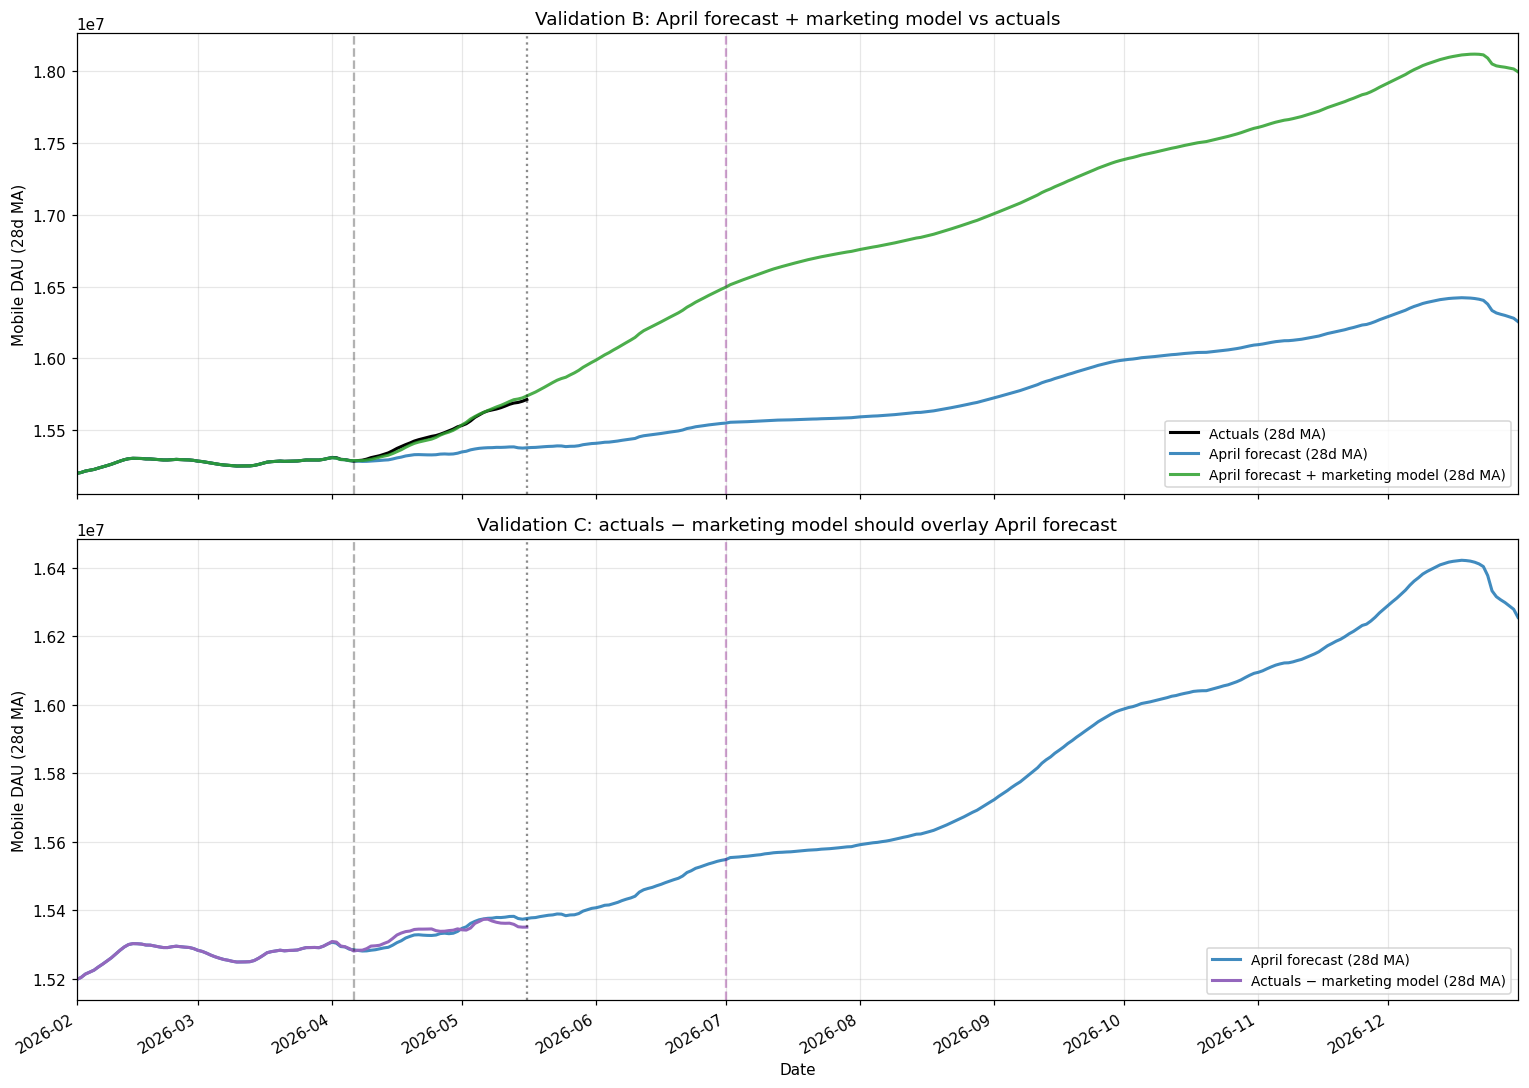

Key values (28d MA, DAU):
        date         actuals           april      april+mktg    actuals−mktg
  2026-04-06     +15,282,455     +15,284,336     +15,286,194     +15,280,597
  2026-05-01     +15,531,103     +15,346,816     +15,535,251     +15,342,668
  2026-05-16     +15,712,657     +15,375,573     +15,737,713     +15,350,517
  2026-07-01                     +15,548,035     +16,496,201                
  2026-09-01                     +15,723,116     +17,007,830                
  2026-12-15                     +16,416,911     +18,098,678                

Counterfactual residual: (actuals − marketing) − April forecast (28d MA)
  N days: 105
  Mean:         +968 DAU
  Std:        +9,137 DAU
  Min:       -25,056 DAU (at 2026-05-16)
  Max:       +22,530 DAU (at 2026-04-17)


In [14]:
# [plot-scaled-validation]
# Validation B: does April forecast + marketing-lift model overlay actuals?
# Validation C: does (actuals − marketing-lift model) overlay April forecast?
# Both views in 28d trailing MA space.

PLOT_START = pd.Timestamp('2026-02-01')
PLOT_END = pd.Timestamp('2026-12-31')
plot_index = pd.date_range(PLOT_START, PLOT_END, freq='D')

actuals_ma_v = actuals_mobile.rolling(window=28, min_periods=14).mean().reindex(plot_index)
april_ma_v = april_full_mobile.rolling(window=28, min_periods=14).mean().reindex(plot_index)
marketing_ma_v = marketing_lift_ma.reindex(plot_index).fillna(0.0)
combined_ma_v = april_ma_v + marketing_ma_v
actuals_minus_marketing_v = actuals_ma_v - marketing_ma_v

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax_top.plot(actuals_ma_v.index, actuals_ma_v, '-', linewidth=2, color='black',
            label='Actuals (28d MA)')
ax_top.plot(april_ma_v.index, april_ma_v, '-', linewidth=2, color='C0', alpha=0.85,
            label='April forecast (28d MA)')
ax_top.plot(combined_ma_v.index, combined_ma_v, '-', linewidth=2, color='C2', alpha=0.85,
            label='April forecast + marketing model (28d MA)')
ax_top.set_title('Validation B: April forecast + marketing model vs actuals')
ax_top.set_ylabel('Mobile DAU (28d MA)')
ax_top.legend(fontsize=9, loc='lower right')

ax_bot.plot(april_ma_v.index, april_ma_v, '-', linewidth=2, color='C0', alpha=0.85,
            label='April forecast (28d MA)')
have_actuals = actuals_ma_v.notna()
ax_bot.plot(actuals_minus_marketing_v.index[have_actuals],
            actuals_minus_marketing_v[have_actuals],
            '-', linewidth=2, color='C4',
            label='Actuals − marketing model (28d MA)')
ax_bot.set_title('Validation C: actuals − marketing model should overlay April forecast')
ax_bot.set_ylabel('Mobile DAU (28d MA)')
ax_bot.set_xlabel('Date')
ax_bot.legend(fontsize=9, loc='lower right')

for ax in (ax_top, ax_bot):
    ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.3)
    ax.axvline(LAST_HISTORICAL_DATE, color='black', linestyle=':', alpha=0.45)
    ax.axvline(SLOPE_BREAK, color='purple', linestyle='--', alpha=0.35)
    ax.set_xlim(PLOT_START, PLOT_END)

ax_bot.xaxis.set_major_locator(mdates.MonthLocator())
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print('Key values (28d MA, DAU):')
print(f'  {"date":>10}  {"actuals":>14}  {"april":>14}  {"april+mktg":>14}  {"actuals−mktg":>14}')
for day in [CAMPAIGN_LAUNCH, pd.Timestamp('2026-05-01'), LAST_HISTORICAL_DATE,
            SLOPE_BREAK, pd.Timestamp('2026-09-01'), pd.Timestamp('2026-12-15')]:
    if day not in plot_index:
        continue
    a = actuals_ma_v.loc[day]
    f = april_ma_v.loc[day]
    c = combined_ma_v.loc[day]
    am = actuals_minus_marketing_v.loc[day]

    def _fmt(v):
        return f'{v:>+14,.0f}' if pd.notna(v) else f'{"":>14}'

    print(f'  {day.strftime("%Y-%m-%d"):>10}  {_fmt(a)}  {_fmt(f)}  {_fmt(c)}  {_fmt(am)}')

counterfactual_residual = (actuals_minus_marketing_v - april_ma_v).dropna()
print(f'\nCounterfactual residual: (actuals − marketing) − April forecast (28d MA)')
print(f'  N days: {len(counterfactual_residual)}')
print(f'  Mean:   {counterfactual_residual.mean():>+10,.0f} DAU')
print(f'  Std:    {counterfactual_residual.std():>+10,.0f} DAU')
print(f'  Min:    {counterfactual_residual.min():>+10,.0f} DAU (at {counterfactual_residual.idxmin().date()})')
print(f'  Max:    {counterfactual_residual.max():>+10,.0f} DAU (at {counterfactual_residual.idxmax().date()})')


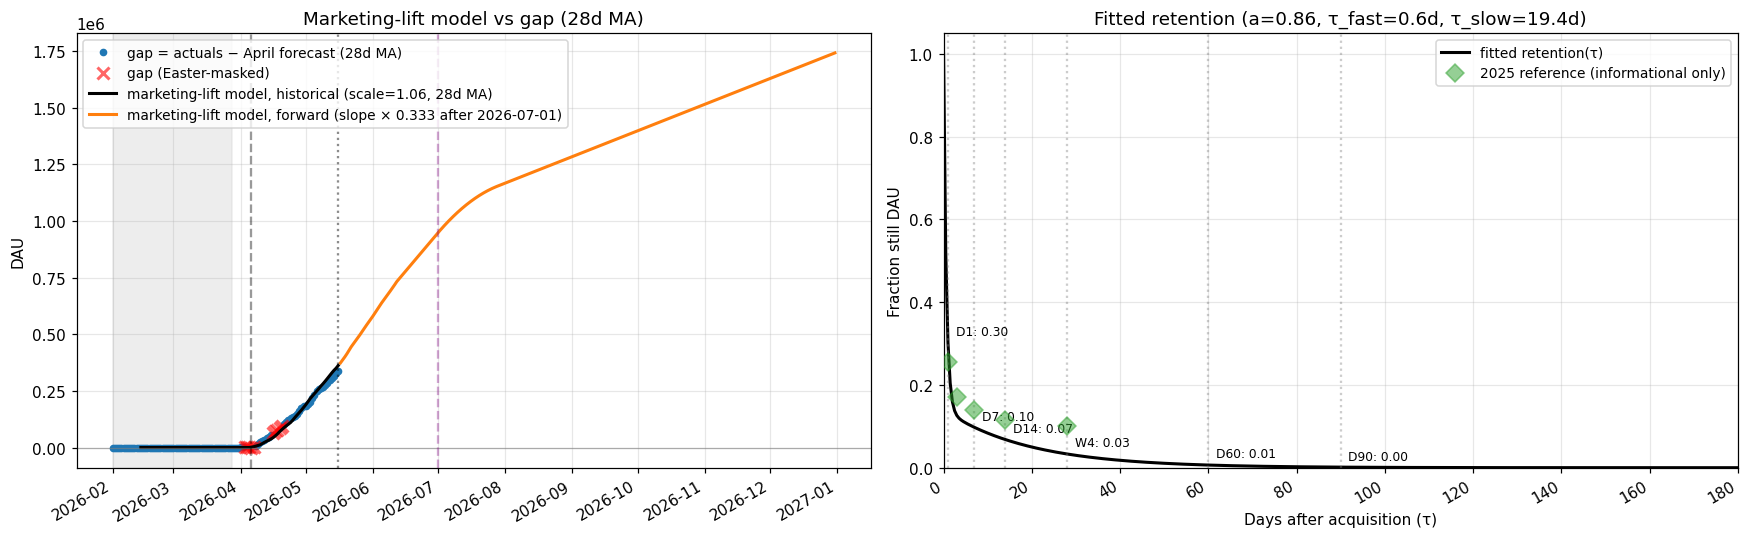

In [15]:
# [plot-final-model]
# Summary plot for the exported model — mirrors 02:[plot-retention-fit] style.
#
# Left:  the fit (marketing-lift model, 28d MA) vs the data (gap = actuals −
#        April forecast, 28d MA). Historical fit window + forward projection.
# Right: the fitted retention curve with anchor markers from the 2025 paid
#        Playstore reference cohort (informational; not in any loss).
#        Hardcoded from 02:[retention-fit]:HISTORICAL_RETENTION_REFERENCE.

fig, (ax_fit, ax_kernel) = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: fit vs data ------------------------------------------------------

PLOT_START = pd.Timestamp('2026-02-01')
PLOT_END = FORECAST_END
plot_index = pd.date_range(PLOT_START, PLOT_END, freq='D')

gap_ma_plot = gap_ma.reindex(plot_index)
mktg_ma_plot = marketing_lift_ma.reindex(plot_index)

hist_mask = plot_index <= LAST_HISTORICAL_DATE
fwd_mask = plot_index > LAST_HISTORICAL_DATE
easter_in_plot = plot_index.isin(EASTER_MASK_DATES)

ax_fit.plot(plot_index, gap_ma_plot, '-', linewidth=1.0, color='C0', alpha=0.35)
ax_fit.plot(plot_index[~easter_in_plot], gap_ma_plot[~easter_in_plot],
            'o', markersize=4, color='C0', label='gap = actuals − April forecast (28d MA)')
ax_fit.plot(plot_index[easter_in_plot], gap_ma_plot[easter_in_plot],
            'x', markersize=8, color='red', markeredgewidth=2, alpha=0.6,
            label='gap (Easter-masked)')
ax_fit.plot(plot_index[hist_mask], mktg_ma_plot[hist_mask],
            '-', linewidth=2, color='black',
            label=f'marketing-lift model, historical (scale={SCALE_FACTOR:.2f}, 28d MA)')
ax_fit.plot(plot_index[fwd_mask], mktg_ma_plot[fwd_mask],
            '-', linewidth=2, color='C1',
            label=f'marketing-lift model, forward (slope × {SLOPE_REDUCTION_FACTOR:.3f} after {SLOPE_BREAK.date()})')

ax_fit.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
ax_fit.axvspan(BASELINE_START, BASELINE_END, color='lightgrey', alpha=0.4)
ax_fit.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4)
ax_fit.axvline(LAST_HISTORICAL_DATE, color='black', linestyle=':', alpha=0.45)
ax_fit.axvline(SLOPE_BREAK, color='purple', linestyle='--', alpha=0.35)

ax_fit.set_title('Marketing-lift model vs gap (28d MA)')
ax_fit.set_ylabel('DAU')
ax_fit.legend(fontsize=9, loc='upper left')
ax_fit.xaxis.set_major_locator(mdates.MonthLocator())
ax_fit.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# --- Right: fitted retention curve with 2025 reference anchors --------------
# Hardcoded from 02:[retention-fit]:HISTORICAL_RETENTION_REFERENCE — these are
# the 2025 paid Playstore cohort retention values, informational only.
HISTORICAL_RETENTION_REFERENCE = {1: 0.256, 3: 0.170, 7: 0.139, 14: 0.116, 28: 0.100}

tau_grid = np.linspace(0, 180, 361)
retention_grid = retention(tau_grid)

ax_kernel.plot(tau_grid, retention_grid, '-', linewidth=2, color='black',
               label='fitted retention(τ)')

ref_lags = np.array(list(HISTORICAL_RETENTION_REFERENCE.keys()))
ref_vals = np.array(list(HISTORICAL_RETENTION_REFERENCE.values()))
ax_kernel.plot(ref_lags, ref_vals, 'D', markersize=8, color='C2', alpha=0.5,
               label='2025 reference (informational only)', zorder=5)

for tau_marker, label in [(1, 'D1'), (7, 'D7'), (14, 'D14'), (28, 'W4'), (60, 'D60'), (90, 'D90')]:
    val = retention(tau_marker)
    ax_kernel.axvline(tau_marker, color='grey', linestyle=':', alpha=0.4)
    ax_kernel.annotate(f'{label}: {val:.2f}', xy=(tau_marker, val),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)

ax_kernel.set_xlabel('Days after acquisition (τ)')
ax_kernel.set_ylabel('Fraction still DAU')
ax_kernel.set_xlim(0, 180)
ax_kernel.set_ylim(0, 1.05)
ax_kernel.set_title(f'Fitted retention (a={A:.2f}, τ_fast={TAU_FAST:.1f}d, τ_slow={TAU_SLOW:.1f}d)')
ax_kernel.legend(fontsize=9)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [16]:
# [export-model]
# Export the marketing-lift model for consumption by the main mozaic-daily
# workflow as an overlay/adjustment series.
#
# Files written (both in marketing_lift_model/data/):
#   - marketing_lift_model.{LAST_HISTORICAL_DATE}.parquet
#       Columns: target_date (index), marketing_lift_daily, marketing_lift_ma
#       Coverage: full series, earliest historical date → FORECAST_END.
#       Pre-CAMPAIGN_LAUNCH values are 0.
#   - marketing_lift_model.{LAST_HISTORICAL_DATE}.meta.json
#       Full model provenance: retention params, scale factor, anchor slope,
#       source notebook list, source forecast parquet paths, git hash.

import subprocess


def _git_hash():
    try:
        result = subprocess.run(
            ['git', 'rev-parse', 'HEAD'],
            capture_output=True, text=True, check=False,
        )
        return result.stdout.strip() if result.returncode == 0 else None
    except Exception:
        return None


export_df = pd.DataFrame({
    'marketing_lift_daily': marketing_lift_daily,
    'marketing_lift_ma':    marketing_lift_ma,
})
export_df.index.name = 'target_date'

export_date_str = LAST_HISTORICAL_DATE.strftime('%Y-%m-%d')
out_parquet = DATA_DIR / f'marketing_lift_model.{export_date_str}.parquet'
out_meta = DATA_DIR / f'marketing_lift_model.{export_date_str}.meta.json'

metadata = {
    'model_name': 'fenix_marketing_lift_v1',
    'description': (
        'Daily marketing-attributable DAU lift for the Fenix Android campaign '
        'launched 2026-04-06. Historical portion is (Fenix NP ⊛ retention) '
        'scaled to match (actuals − April mozaic forecast) at the ex-Iran '
        'ALL-MOBILE rollup. Forward portion is piecewise linear with a slope '
        'break at SLOPE_BREAK reducing the slope to SLOPE_REDUCTION_FACTOR '
        '× initial.'
    ),
    'created_at_utc': pd.Timestamp.utcnow().isoformat(),
    'mozaic_daily_git_hash': _git_hash(),
    'coverage': {
        'start_date':        marketing_lift_daily.index.min().strftime('%Y-%m-%d'),
        'end_date':          marketing_lift_daily.index.max().strftime('%Y-%m-%d'),
        'campaign_launch':   CAMPAIGN_LAUNCH.strftime('%Y-%m-%d'),
        'last_historical':   LAST_HISTORICAL_DATE.strftime('%Y-%m-%d'),
        'slope_break':       SLOPE_BREAK.strftime('%Y-%m-%d'),
        'forecast_end':      FORECAST_END.strftime('%Y-%m-%d'),
    },
    'retention_curve': {
        'a':                              A,
        'tau_fast':                       TAU_FAST,
        'tau_slow':                       TAU_SLOW,
        'integrated_retention_user_days': INTEGRATED_RETENTION_MODEL,
        'source_fit_file':                str(fit_path.resolve()),
    },
    'historical_scaling': {
        'scale_factor':                SCALE_FACTOR,
        'fenix_lift_28d_ma_post_mean': float(fenix_lift_ma_mean_post),
        'gap_28d_ma_post_mean':        float(gap_ma_mean_post),
        'compare_window_n_days':       int(len(compare_dates)),
        'easter_mask_dates':           [d.strftime('%Y-%m-%d') for d in EASTER_MASK_DATES],
    },
    'forward_projection': {
        'anchor_slope_dau_per_day':         ANCHOR_SLOPE,
        'post_break_slope_dau_per_day':     ANCHOR_SLOPE * SLOPE_REDUCTION_FACTOR,
        'slope_reduction_factor':           SLOPE_REDUCTION_FACTOR,
        'slope_window_days':                SLOPE_WINDOW_DAYS,
        'pin_value_at_last_historical_dau': pin_value,
    },
    'source_data': {
        'april_forecast_parquet': APRIL_FORECAST_PATH,
        'june_forecast_parquet':  JUNE_FORECAST_PATH,
        'rollup_filter': (
            "data_source='glean_mobile', country='ALL', app_name='ALL MOBILE', "
            "segment='{}'; underlying signal is Fenix Android release-channel, "
            "ex-IR, ex-fa locale."
        ),
    },
    'source_notebooks': [
        '01_signal_extraction.ipynb',
        '02_retention_fit.ipynb',
        '03_forecast_projection.ipynb',
    ],
    'export_columns': {
        'marketing_lift_daily': (
            'Daily DAU lift attributable to the campaign. Subtract from '
            'mobile actuals before mozaic forecasting; add back to the '
            'forecast post-hoc.'
        ),
        'marketing_lift_ma': (
            '28-day trailing moving average of marketing_lift_daily, for '
            'diagnostics. NaN for the first 14 days of the series.'
        ),
    },
}

export_df.to_parquet(out_parquet)
with open(out_meta, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Wrote marketing-lift model:')
print(f'  parquet → {out_parquet.resolve()}  ({out_parquet.stat().st_size / 1024:.1f} KB)')
print(f'  meta    → {out_meta.resolve()}')
print()
print(f'Series spans {marketing_lift_daily.index.min().date()} '
      f'→ {marketing_lift_daily.index.max().date()} '
      f'({len(marketing_lift_daily)} days)')
print(f'Daily lift on key dates:')
for day in [CAMPAIGN_LAUNCH, LAST_HISTORICAL_DATE, SLOPE_BREAK,
            pd.Timestamp('2026-12-15'), FORECAST_END]:
    val = marketing_lift_daily.get(day, float('nan'))
    if pd.notna(val):
        print(f'  {day.strftime("%Y-%m-%d")}: {val:>+14,.0f} DAU')


Wrote marketing-lift model:
  parquet → /Users/brendanwells/work/mozaic-daily/.claude/worktrees/marketing-lift/marketing_lift_model/data/marketing_lift_model.2026-05-16.parquet  (10.4 KB)
  meta    → /Users/brendanwells/work/mozaic-daily/.claude/worktrees/marketing-lift/marketing_lift_model/data/marketing_lift_model.2026-05-16.meta.json

Series spans 2026-02-01 → 2026-12-31 (334 days)
Daily lift on key dates:
  2026-04-06:        +52,023 DAU
  2026-05-16:       +579,474 DAU
  2026-07-01:     +1,101,314 DAU
  2026-12-15:     +1,732,816 DAU
  2026-12-31:     +1,793,319 DAU
